# Brownian Motion and Geometric Brownian Motion
This notebook contains solutions to the following questions:

1. Simulate a single path of a one-dimensional Wiener process (standard Brownian motion) over the interval [0, T].
2. Simulate 5 paths of a geometric Brownian motion in a single plot.
3. Show that for standard Brownian motion, E[W_s W_t] = min(s, t).
4. Show that W_t - W_s ~ N(0, t - s) and increments over non-overlapping intervals are independent.
5. Show that E[W_t | F_s] = W_s, concluding that Brownian motion is a martingale.

## Q1: Simulate a single Wiener process path
We simulate a single path of standard Brownian motion on [0, T] by generating normal increments.

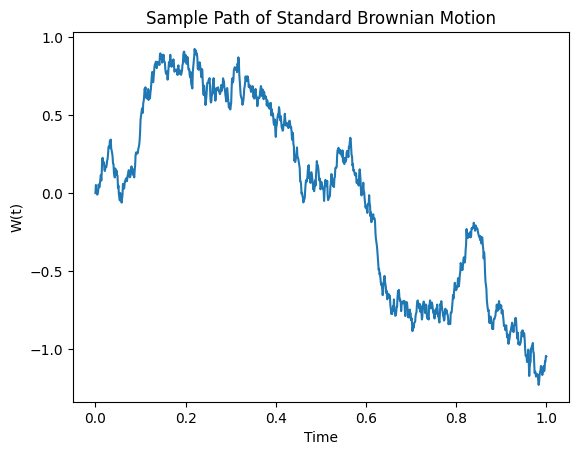

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 1.0
N = 1000
dt = T / N

# Simulate increments and path
increments = np.random.normal(0, np.sqrt(dt), size=N)
W = np.concatenate(([0], np.cumsum(increments)))

# Plot the path
t = np.linspace(0, T, N+1)
plt.plot(t, W)
plt.title("Sample Path of Standard Brownian Motion")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.show()

## Q2: Simulate 5 paths of Geometric Brownian Motion

We use:
$$S(t) = S(0) \exp\left(\sigma W(t) + \left(\alpha - \frac{1}{2}\sigma^2\right)t\right).$$

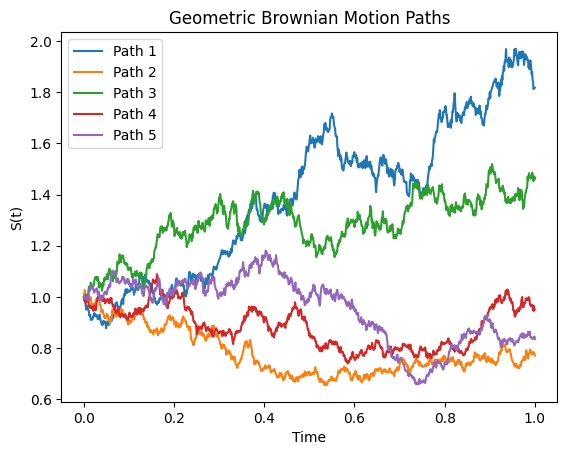

In [2]:
# Parameters
S0 = 1.0
alpha = 0.1
sigma = 0.3
T = 1.0
N = 1000
dt = T / N

# Simulate 5 paths
t = np.linspace(0, T, N+1)
plt.figure()
for i in range(5):
    increments = np.random.normal(0, np.sqrt(dt), size=N)
    W = np.concatenate(([0], np.cumsum(increments)))
    S = S0 * np.exp(sigma * W + (alpha - 0.5 * sigma**2) * t)
    plt.plot(t, S, label=f"Path {i+1}")

plt.title("Geometric Brownian Motion Paths")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.legend()
plt.show()

## Q3: Covariance of Brownian Motion


In [3]:
import numpy as np

# Simulation parameters
s, t = 0.3, 0.7
T = t
N = 1000
dt = T / N
M = 100000  # number of simulations

# Simulate paths up to t
estimates = []
for _ in range(M):
    increments = np.random.normal(0, np.sqrt(dt), size=N)
    W = np.concatenate(([0], np.cumsum(increments)))
    # find indices
    idx_s = int(s/dt)
    idx_t = int(t/dt)
    estimates.append(W[idx_s] * W[idx_t])

print(f"Estimated E[W({s})W({t})] ≈ {np.mean(estimates):.4f}, min(s,t) = {min(s,t):.4f}")

Estimated E[W(0.3)W(0.7)] ≈ 0.3024, min(s,t) = 0.3000


## Q4: Distribution and Independence of Increments

### Computational Demonstration for Q4
1. Show $W_t - W_s \sim N(0, t-s)$.
2. Show independence via covariances of non-overlapping increments.

In [4]:
import numpy as np

# Parameters
s, t = 0.4, 0.9
T = t
N = 1000
dt = T / N
M = 100000

increments_list = []
diffs = []

for _ in range(M):
    increments = np.random.normal(0, np.sqrt(dt), size=N)
    W = np.concatenate(([0], np.cumsum(increments)))
    idx_s = int(s/dt)
    idx_t = int(t/dt)
    delta = W[idx_t] - W[idx_s]
    diffs.append(delta)

# Check mean and variance
print(f"Sample mean ≈ {np.mean(diffs):.4f}, Sample var ≈ {np.var(diffs):.4f}, Expected var t-s = {t-s:.4f}")

# Check independence: covariance between increments on [0,s] and [s,t]
M2 = 50000
covs = []
for _ in range(M2):
    increments = np.random.normal(0, np.sqrt(dt), size=N)
    W = np.concatenate(([0], np.cumsum(increments)))
    inc1 = W[int(s/dt)]
    inc2 = W[int(t/dt)] - W[int(s/dt)]
    covs.append(inc1 * inc2)
print(f"Estimated Cov = {np.mean(covs):.4e}, should be ~0")

Sample mean ≈ 0.0002, Sample var ≈ 0.4982, Expected var t-s = 0.5000
Estimated Cov = 2.5746e-03, should be ~0


## Q5: Martingale Property
We show $E[W_t \mid \mathcal{F}_s] = W_s$ for $0 \le s \le t$.  

In [5]:
# Computational snippet for Q5: verifying E[W_t | W_s] = W_s via linear regression
s, t = 0.5, 1.0      # choose times with s < t
N = 1000            # discretization steps up to t
dt = t / N
M = 200000         # number of simulated paths

# Simulate many (W_s, W_t) pairs
Ws = np.empty(M)
Wt = np.empty(M)
for i in range(M):
    increments = np.random.normal(0, np.sqrt(dt), size=N)
    W = np.concatenate(([0], np.cumsum(increments)))
    Ws[i] = W[int(s / dt)]
    Wt[i] = W[-1]

# Fit linear regression: Wt ≈ a + b * Ws
b, a = np.polyfit(Ws, Wt, 1)

print(f"Estimated E[W_t | W_s] ≈ {a:.4f} + {b:.4f} * W_s")
print("Expected: intercept ≈ 0, slope ≈ 1")


Estimated E[W_t | W_s] ≈ 0.0031 + 1.0008 * W_s
Expected: intercept ≈ 0, slope ≈ 1
